<a href="https://colab.research.google.com/github/anyatrs/-/blob/MIPT-Master's-Degree/HW1_%D0%A2%D0%B0%D1%80%D0%B0%D1%81%D0%BE%D0%B2%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!pip install marimo -qq
import marimo as mo

## Домашнее задание 1
### Цель задания

Сегодня ваша задача как гейм-аналитика — написать код,  чтобы найти наиболее прибыльные жанры игр и решить, какие 3 игры продаются лучше всех.

### Навыки

|Архитектура|Базы данных|Форматы данных|Инструменты|Коммуникации|ИИ     |
|-----------|-----------|--------------|-----------|------------|-------|
|Отсутствует|нет        |CSV/JSON      |Git        |нет         |ChatGPT|

### Условия

Можно пользоваться любыми языковыми моделями.

###  Формат сдачи и отправка задания

Итоговый блокнот нужно разместить на GitLab либо на GitHub («запушить» в любом формате .py или .ipynb)
и поделиться ссылкой на файл (убедившись в видимости репозитория).

###  Критерии оценивания

| Критерий | Вес | Описание |
|----------|-----|-----------|
| **Основная функциональность** | 2 | Все основные требования задания выполнены корректно (задания 2 и 4) |
| | 1 | Большая часть требований выполнена, но есть незначительные недочеты или пропуски |
|  | 0 | Основные требования не выполнены или выполнены некорректно|
| **Выбор алгоритма** | 1.5 | Выбранные подходы и алгоритмы (например, groupby().sum()) оптимальны и уместны для задачи |
|  | 0.5 | Подходы в целом верны, но могли бы быть более эффективными или уместными |
|  | 0 | Подходы не соответствуют задаче |
| **Точность реализации** | 1.5 | Код реализован корректно, без ошибок, расчеты точны, логика полностью соответствует задаче |
|  | 0.5 | Есть мелкие неточности или логические ошибки, не влияющие критически на результат |
|  | 0 | Содержит существенные ошибки, препятствующие получению верного результата|
| **Обработка краевых случаев** | 1 | Код устойчив к различным входным данным, учтены потенциальные краевые условия |
|  | 0 | Краевые случаи не учтены, возможны ошибки в специфических сценариях |
| **Документация к коду** | 1 | Код прокомментирован, комментарии ясны, помогают понять логику |
|  | 0 | Комментарии отсутствуют или бесполезны |
| **Объяснение результатов** | 1 | Выводы по результатам работы кода четкие, логичные и обоснованные данными |
|  | 0 | Выводы отсутствуют или не имеют отношения к данным |
| **Стиль кода** | 1 | Код читаем, соответствует стандартам PEP-8 |
|  | 0 | Код плохо читаем, стандарты стиля не соблюдены |
| **Анализ ошибок и отладка** | 1 | Способность выявить, понять и исправить ошибку (задание 5) показана полностью и эффективно |
|  | 0 | Ошибка не исправлена или понимание ее причин отсутствует |


**Максимальный балл за выполненную домашнюю работу: 10 баллов**

**Дополнительные условия оценки:**

Можно сдать работу через обычный Google Colab без начисления штрафных баллов и поделиться ссылкой на файл.

**Как будет проверяться:**

Работа будет проверяться преподавателем вручную в течение максимум одной недели.

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
file_id = '1y1fqg7yWO6ifgnyJkuZ8IwmMqZjNCUq_'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
videogames_dataset = pd.read_csv(url)
videogames_dataset.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


### **Задание 1**

Поработайте с кодом выше и скачайте датасет. Используя промпт ниже, скормите вашей LLM датасет и получите описание набора данных.
```
опишите набор данных на русском языке @videogames_dataset
```

#### Хорошая новость — вы моментально получите описание набора данных.

Данный набор данных содержит информацию о видеоиграх. Вот описание каждого столбца:

- `Name`: название видеоигры;
- `Platform`: платформа, для которой была выпущена игра (например, Wii, NES);
- `Year_of_Release`: год выпуска игры;
- `Genre`: жанр игры (например, спорт, гонки);
- `Publisher`: издатель игры;
- `NA_Sales`: продажи в Северной Америке (в миллионах единиц);
- `EU_Sales`: продажи в Европе (в миллионах единиц);
- `JP_Sales`: продажи в Японии (в миллионах единиц);
- `Other_Sales`: продажи в других регионах (в миллионах единиц);
- `Global_Sales`: глобальные продажи (в миллионах единиц);
- `Critic_Score`: оценка критиков (максимально 100);
- `Critic_Count`: количество оценок критиков;
- `User_Score`: оценка пользователей (обычно до 10);
- `User_Count`: количество оценок пользователей;
- `Developer`: разработчик игры;
- `Rating`: рейтинг ESRB (возрастная категория игры).

#### Плохая новость — за выполнение задания таким образом вы получите ноль баллов.

 Почему?

 Вы не писали код при выполнении этого задания.

 Мы здесь для того, чтобы научиться писать код при работе с данными.

## ***Далее идет небольшое описание датасета для себя***

In [55]:
#Выведем основную информацию о датасете, чтобы в дальнейшем с ним было проще работать:
print("ОСНОВНАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ:")
print(f"   • Размер датасета: {videogames_dataset.shape[0]} строк, {videogames_dataset.shape[1]} столбцов")
print(f"   • Период, за которые нам были предоставлены данные : {int(videogames_dataset['Year_of_Release'].min())} - {int(videogames_dataset['Year_of_Release'].max())} год")
print()

print("СВОДКА О СТРУКТУРЕ ДАТАСЕТА:")
print(videogames_dataset.info())
print()

print("ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ ПО КАЖДОМУ ИЗ ПРИЗНАКОВ:")
missing_values = videogames_dataset.isnull().sum()
print(missing_values[missing_values > 0])
print()

print("СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ:")
print(videogames_dataset[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].describe().round(2))
print()

print("КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ:")
print(f"   • Платформ: {videogames_dataset['Platform'].nunique()} уникальных")
print(f"   • Жанров: {videogames_dataset['Genre'].nunique()} уникальных")
print(f"   • Издателей: {videogames_dataset['Publisher'].nunique()} уникальных")
print()

print("РАСПРЕДЕЛЕНИЕ ИГР ПО ЖАНРАМ:")
genre_distribution = videogames_dataset['Genre'].value_counts()
print(genre_distribution)
print()

print("РАСПРЕДЕЛЕНИЕ ИГР ПО ПЛАТФОРМАМ:")
platform_distribution = videogames_dataset['Platform'].value_counts().head(10)
print(platform_distribution)

ОСНОВНАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ:
   • Размер датасета: 16719 строк, 16 столбцов
   • Период, за которые нам были предоставлены данные : 1980 - 2020 год

СВОДКА О СТРУКТУРЕ ДАТАСЕТА:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       7590 non-null   float64
 13  User_Count     

### **Задание 2**



Сделайте вывод: какие три жанра игр приносят наибольшую выручку?

In [56]:
def analyze_genre(df): #Сгруппируем данные по жанрам и просуммируем продажи
    genre_sales = df.groupby('Genre').agg({
        'NA_Sales': 'sum',
        'EU_Sales': 'sum',
        'JP_Sales': 'sum',
        'Other_Sales': 'sum',
        'Global_Sales': 'sum'
    }).round(2)

    genre_sales_sorted = genre_sales.sort_values('Global_Sales', ascending=False)
    #Отсортируем по глобальным продажам, чтобы в дальнейшем было проще получить информацию по топ-3 жанрам по мировым продажам

    return genre_sales_sorted

genre_analysis = analyze_genre(videogames_dataset)

print("АНАЛИЗ ПРОДАЖ ПО ЖАНРАМ (в миллионах копий)")
print(genre_analysis)
print()

print("ТОП-3 ЖАНРА ПО ГЛОБАЛЬНЫМ ПРОДАЖАМ")
top_3_global = genre_analysis.head(3)
for i, (genre, sales) in enumerate(top_3_global['Global_Sales'].items(), 1):
    print(f"{i}. 🎯 {genre}: {sales} млн копий")
print()

print("ДЕТАЛЬНЫЙ АНАЛИЗ ТОП-3 ЖАНРОВ ПО РЕГИОНАМ")
for i, (genre, row) in enumerate(top_3_global.iterrows(), 1):
    print(f"\n{i}. 🎯 {genre.upper()}:")
    print(f"   🌍 Всего: {row['Global_Sales']:.1f}M копий")
    print(f"   📊 Доля рынка: {row['Global_Sales']/total_global*100:.1f}%")
    print()
    print(f"   🇺🇸 Северная Америка: {row['NA_Sales']:.1f}M")
    print(f"   🇪🇺 Европа: {row['EU_Sales']:.1f}M")
    print(f"   🇯🇵 Япония: {row['JP_Sales']:.1f}M")
    print(f"   🗺️ Другие регионы: {row['Other_Sales']:.1f}M")

АНАЛИЗ ПРОДАЖ ПО ЖАНРАМ (в миллионах копий)
              NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales
Genre                                                                
Action          879.01    519.13    161.44       184.60       1745.27
Sports          684.43    376.79    135.54       134.51       1332.00
Shooter         592.24    317.34     38.76       104.11       1052.94
Role-Playing    330.81    188.71    355.46        59.63        934.40
Platform        445.50    200.35    130.83        51.09        828.08
Misc            407.27    212.74    108.11        74.39        803.18
Racing          359.35    236.51     56.71        76.10        728.90
Fighting        223.36    100.33     87.48        36.36        447.48
Simulation      182.19    113.52     63.80        30.75        390.42
Puzzle          122.87     50.01     57.31        12.38        243.02
Adventure       105.26     63.54     52.30        16.49        237.69
Strategy         68.55     45.17     49.66    

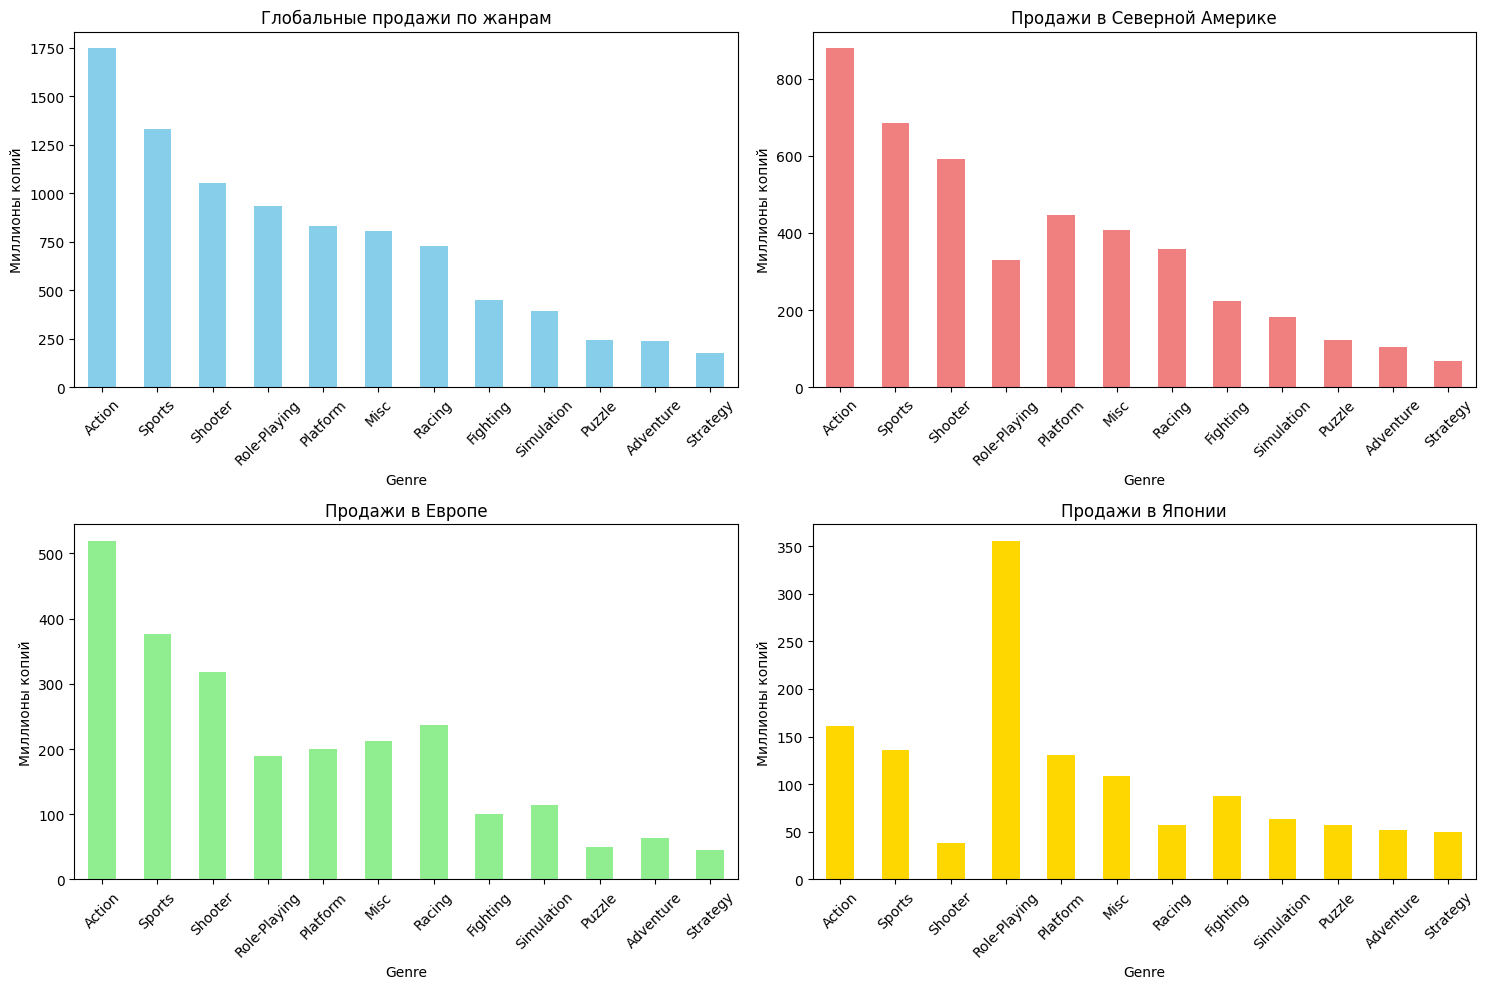

In [57]:
#Визуализация результатов
plt.figure(figsize=(15, 10))

#Глобальные продажи
plt.subplot(2, 2, 1)
genre_analysis['Global_Sales'].plot(kind='bar', color='skyblue')
plt.title('Глобальные продажи по жанрам')
plt.ylabel('Миллионы копий')
plt.xticks(rotation=45)

#Продажи в Северной Америке
plt.subplot(2, 2, 2)
genre_analysis['NA_Sales'].plot(kind='bar', color='lightcoral')
plt.title('Продажи в Северной Америке')
plt.ylabel('Миллионы копий')
plt.xticks(rotation=45)

#Продажи в Европе
plt.subplot(2, 2, 3)
genre_analysis['EU_Sales'].plot(kind='bar', color='lightgreen')
plt.title('Продажи в Европе')
plt.ylabel('Миллионы копий')
plt.xticks(rotation=45)

#Продажи в Японии
plt.subplot(2, 2, 4)
genre_analysis['JP_Sales'].plot(kind='bar', color='gold')
plt.title('Продажи в Японии')
plt.ylabel('Миллионы копий')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Мне показалось интересным посмотреть на этот вопрос немного шире: в разрезе глобальных и локальных трендов. Такой подход будет более корректным при работе с несколькими рынками.

Если говорить о **"мировом"/глобальном рынке**, то в тройку лидеров выделяются следующие жанры:
* Action - около 20% доли рынка;
* Sports - около 15% доли рынка;
* Shooter - около 12% доли рынка.

**Такое положение дел актуально для Европейских стран и Северной Америки. Однако, если мы посмотрим на график для Японии, то обнаружим, что самым популярным являестя жанр Role-Playing игр.** Причем количество проданных копий превышает популярные в Америке и Европе Action игры более чем в 2 раза. Далее с большим отрывомидут уже знакомые нам Action и Sports игры.

### **Задание 3**

Вы сохраняли результат своей работы локально. Насколько это удобно с точки зрения работы в компании, где в работу вовлечены коллегами?


1. Самое главное преимущество на мо взгляд - возможность работать над проектом совместно с коллегами. Мы можем делать это одновременно,при этом каждый из нас сможет просмотреть предыдущие версии того или иного ноутбука.

2. Отдельно стоит отметить автоматический бэкап кода, что позволяет свести к минмуму потерю данных в случае каких-то сбоев.

3. Есть минус: необходимо проводить аудит и менеджмент доступов для сотрудников. Но тут же можно отметить и плюс: гранулярность/вариативность уровней доступа к данным. В целом проблема полностью может быть решена при наличии корпоративной версии GitHub.

### **Задание 4**

Подтвердите или опровергните вывод о том, что первые три строчки в глобальных продажах Nintendo занимают игры:

- Wii Sports;
- Super Mario Bros;
- Mario Kart Wii.

In [58]:
def verify_nintendo_top_games(df):
    #Сортируем данные в датасете по глобальным продажам по убыванию
    top_games = df.nlargest(10, 'Global_Sales')[['Name', 'Publisher', 'Global_Sales']].copy()
    top_games['Rank'] = range(1, len(top_games) + 1)

    #Проверяем топ-три позиции
    first_three = top_games.head(3)
    nintendo_in_top_3 = all(first_three['Publisher'] == 'Nintendo')

    #Проверяем входят ли в наш топ-три заданные игры
    expected_games = ['Wii Sports', 'Super Mario Bros.', 'Mario Kart Wii']
    actual_games = first_three['Name'].tolist()
    games_match = all(expected_games[i] == actual_games[i] for i in range(3))

    #Информация о каждой игре в топ-три
    game_details = []
    for i, (idx, row) in enumerate(first_three.iterrows(), 1):
        game_details.append({
            'Rank': i,
            'Name': row['Name'],
            'Publisher': row['Publisher'],
            'Global_Sales': row['Global_Sales'],
            'Is_Nintendo': row['Publisher'] == 'Nintendo',
            'Is_Expected_Game': row['Name'] == expected_games[i-1]
        })

    return {
        'nintendo_dominates_top_3': nintendo_in_top_3,
        'games_match_expectation': games_match,
        'top_3_games': game_details,
        'verification_result': nintendo_in_top_3 and games_match
    }

#Выполняем саму проверку
results = verify_nintendo_top_games(videogames_dataset)

print("\n🎯 ТОП-3 ИГР ПО ГЛОБАЛЬНЫМ ПРОДАЖАМ:")
print()
for game in results['top_3_games']:
    status = "✅" if game['Is_Nintendo'] and game['Is_Expected_Game'] else "❌"
    print(f"{status} {game['Rank']}. {game['Name']}")
    print(f"   Издатель: {game['Publisher']}")
    print(f"   Продажи: {game['Global_Sales']} млн копий")

print(f"\n🔍 РЕЗУЛЬТАТ ПРОВЕРКИ: {'ПОДТВЕРЖДЕНО✅' if results['verification_result'] else 'ОПРОВЕРГНУТО❌'}")


🎯 ТОП-3 ИГР ПО ГЛОБАЛЬНЫМ ПРОДАЖАМ:

✅ 1. Wii Sports
   Издатель: Nintendo
   Продажи: 82.53 млн копий
✅ 2. Super Mario Bros.
   Издатель: Nintendo
   Продажи: 40.24 млн копий
✅ 3. Mario Kart Wii
   Издатель: Nintendo
   Продажи: 35.52 млн копий

🔍 РЕЗУЛЬТАТ ПРОВЕРКИ: ПОДТВЕРЖДЕНО✅


#### **Вывод корректен.**

К числу трех самых продаваемых игр для Nintendo дейтсвительно относятся:
- Wii Sports;
- Super Mario Bros;
- Mario Kart Wii



### **Задание 5**

При написании кода разработчики и дата-сайентисты допускают ошибки. Это нормально — ошибки неизбежно возникают при создании программного обеспечения. По разным данным, на устранение багов тратится до 25% времени. Допустим, что при выполнении задания №4 вы допустили досадную оплошность и при создании датафрейма указали несуществующий метод **from_dictionary** вместо правильного метода **from_dict**.

1. Скопируйте код ниже.

2. Создайте ячейку с кодом (нажав на кнопку Python внизу).

3. Если вы работаете через marimo notebook, то вставьте код в созданную ячейку и получите ошибку *AttributeError: type object 'DataFrame' has no attribute 'from_dictionary'*
Если вы используете другую среду, обратитесь к LLM напрямую.

4. Если вы работаете через marimo notebook, то исправьте ошибку, нажав на кнопку Fix with AI и затем нажмите Enter в открывшейся ячейке. После завершения генерации нажми Accept справа, чтобы вставить исправленный результат в блокнот.
Если вы используете другую среду, обратитесь к LLM напрямую.


```python
df = pd.DataFrame.from_dictionary([  {"Name":"Wii Sports","Global_Sales":82.53},
                                     {"Name":"Super Mario Bros.","Global_Sales":40.24},
                                     {"Name":"Mario Kart Wii","Global_Sales":35.52}],
                                     orient='columns')
df
```

In [59]:
df = pd.DataFrame.from_dictionary([  {"Name":"Wii Sports","Global_Sales":82.53},
                                     {"Name":"Super Mario Bros.","Global_Sales":40.24},
                                     {"Name":"Mario Kart Wii","Global_Sales":35.52}],
                                     orient='columns')

AttributeError: type object 'DataFrame' has no attribute 'from_dictionary'

In [ ]:
df = pd.DataFrame.from_dict([  {"Name":"Wii Sports","Global_Sales":82.53},
                                     {"Name":"Super Mario Bros.","Global_Sales":40.24},
                                     {"Name":"Mario Kart Wii","Global_Sales":35.52}],
                                     orient='columns')
df

# **Был использован ИИ внутри Google Colab (скрин ниже)**

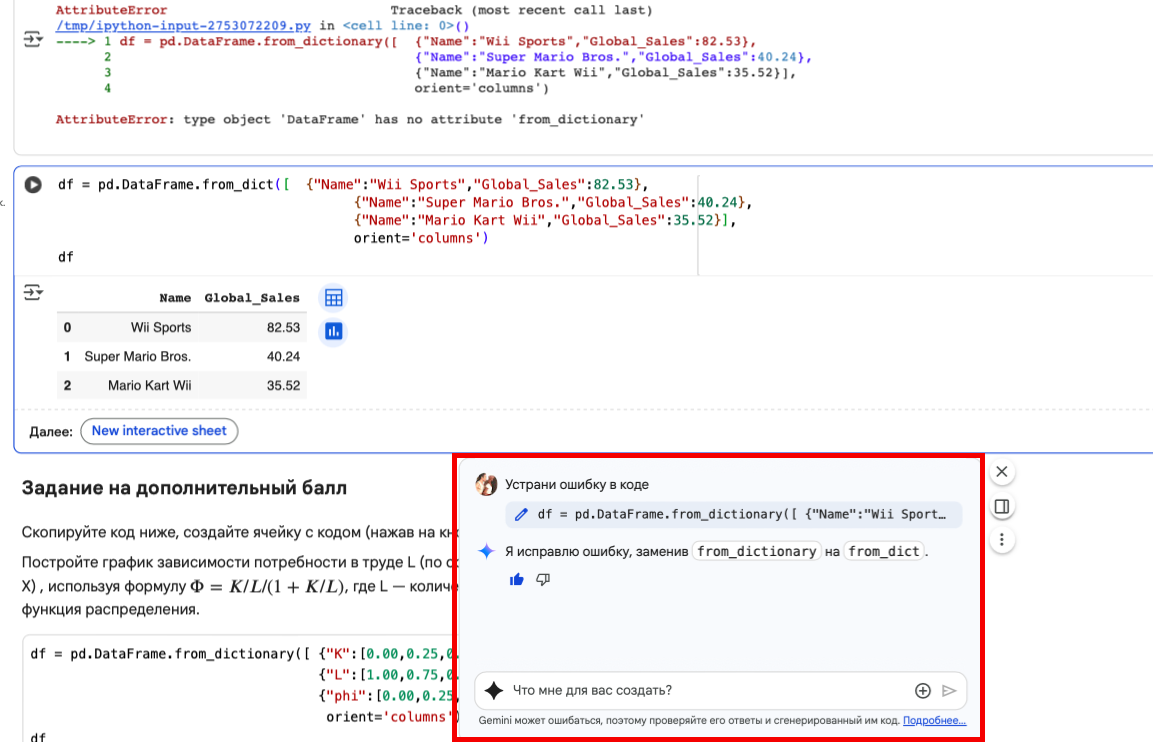

### **Задание на дополнительный балл**

Скопируйте код ниже, создайте ячейку с кодом (нажав на кнопку Python внизу) и вставьте код в созданную ячейку.

Постройте график зависимости потребности в труде L (по оси Y) от доли задач, подлежащих полной автоматизации $Φ(i)$ (по оси Х) ,
используя формулу $Φ = K/L   / (1 + K/L)$, где L — количество единиц рабочей силы, $K$ — количество единиц капитала, $Φ(i)$ — функция распределения.

```python
df = pd.DataFrame.from_dictionary([ {"K":[0.00,0.25,0.50,0.75,1.00]},
                                    {"L":[1.00,0.75,0.50,0.25,0.00]},
                                    {"phi":[0.00,0.25,0.50,0.75,"∞" ]}],
                                     orient='columns')
df
```

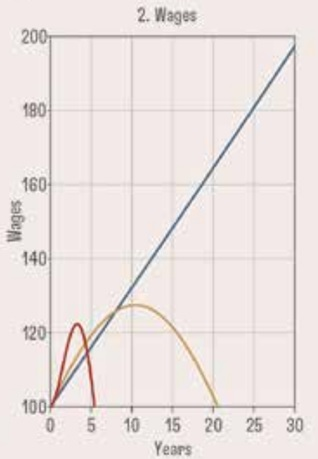

Проведите сравнение заработных плат при разных сценариях полной автоматизации. Для выполнения задания изучите источник: https://www.nber.org/system/files/working_papers/w32255/w32255.pdf

          напишите свой вывод